TODO
- 2 chains 10k iterations
- generate corrolated embeddings, inverse of the covariance, add 1 randomly on off diagonal. https://stats.stackexchange.com/questions/587800/creating-a-random-sparse-precision-matrix
- hwo to fix rotation

In [2]:
import json
import itertools
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def calculate_eta(vi, wi, theta, V):
    rho_v = theta[vi, :]          # ρ_v = θ_v
    alpha_w = theta[wi + V, :]    # α_w = θ_{V + w}
    eta = rho_v.dot(alpha_w)      # η = ρ_v^T α_w
    return eta

def calculate_p(vi, wi, theta, V):
    eta = calculate_eta(vi, wi, theta, V)
    return sigmoid(eta)

def load_fit(size, save_dir):
    filename = os.path.join(save_dir, f'stan_fit_{size}.pkl')
    with open(filename, 'rb') as f:
        fit = pickle.load(f)
    return fit

def calculate_rmse_slow(theta_samples, true_theta, vocabulary):
    V = len(vocabulary)
    
    p_true = []
    p_avg = []

    for word1 in vocabulary:
        for word2 in vocabulary:
            vi = vocabulary[word1]
            wi = vocabulary[word2]
            p_true.append(calculate_p(vi, wi, true_theta, V))

            p_samples = [calculate_p(vi, wi, theta, V) for theta in theta_samples]
            p_avg.append(np.mean(p_samples))
    
    p_true = np.array(p_true)
    p_avg = np.array(p_avg)
    
    rmse = np.sqrt(np.mean((p_true - p_avg) ** 2))
    return rmse

def calculate_rmse(theta_samples, true_theta, vocabulary):
    V = len(vocabulary)
    D = true_theta.shape[1]  # Dimensionality of the embeddings
    
    # Extract rho_v and alpha_w from true_theta
    rho_v = true_theta[:V, :]       # Shape: (V, D)
    alpha_w = true_theta[V:, :]     # Shape: (V, D)
    
    # Compute E_true = rho_v @ alpha_w.T  # Shape: (V, V)
    E_true = np.dot(rho_v, alpha_w.T)
    
    # Compute p_true = sigmoid(E_true)
    p_true = sigmoid(E_true)
    
    # Extract rho_v_samples and alpha_w_samples from theta_samples
    rho_v_samples = theta_samples[:, :V, :]     # Shape: (N, V, D)
    alpha_w_samples = theta_samples[:, V:, :]   # Shape: (N, V, D)
    
    # Compute E_samples = rho_v_samples @ alpha_w_samples.transpose(0, 2, 1)
    # Shape of E_samples: (N, V, V)
    E_samples = np.matmul(rho_v_samples, np.transpose(alpha_w_samples, (0, 2, 1)))
    
    # Compute p_samples = sigmoid(E_samples)
    p_samples = sigmoid(E_samples)
    
    # Compute p_avg = mean over samples axis
    p_avg = np.mean(p_samples, axis=0)  # Shape: (V, V)
    
    # Compute RMSE between p_true and p_avg
    rmse = np.sqrt(np.mean((p_true - p_avg) ** 2))
    return rmse


def extract_word_and_context_vectors_vi2(fit, vocabulary, D=2):
    """
    VI helper: extracts the word and context vectors from the variational parameters.
    """
    variational_samples_pd = fit.variational_params_pd

    # exclude the first three columns (lp__, log_p__, log_g__) and context_vectors_raw
    relevant_params = np.delete(variational_samples_pd, np.s_[3:3+(len(vocabulary)-D)*D], axis=1)
    
    num_samples = relevant_params.shape[0]
    word_vectors = np.zeros((num_samples, len(vocabulary), D))
    context_vectors = np.zeros((num_samples, len(vocabulary), D))
    
    for d in range(D):
        for n in range(len(vocabulary)):
            word_vectors[:, n, d] = relevant_params[:, n + d * len(vocabulary)]
            context_vectors[:, n, d] = relevant_params[:, len(vocabulary) * D + n + d * len(vocabulary)]
    
    return word_vectors, context_vectors


def extract_word_and_context_vectors_vi(samples_pd, vocabulary, D=2):
    """
    VI helper: extracts the word and context vectors from the variational parameters.
    """
    #variational_samples_pd = fit.variational_sample_pd

    # Drop the first three columns: 'lp__', 'log_p__', 'log_g__'
    relevant_params = samples_pd.drop(columns=['lp__','log_p__','log_g__'] , errors='ignore')

    # Drop columns related to 'context_vectors_raw'
    raw_context_columns = [col for col in relevant_params.columns if 'context_vectors_raw' in col]
    relevant_params = relevant_params.drop(columns=raw_context_columns)

    num_samples = relevant_params.shape[0]
    V = len(vocabulary)
    
    word_vectors = np.zeros((num_samples, V, D))
    context_vectors = np.zeros((num_samples, V, D))
    
    for d in range(D):
        for n in range(V):
            word_vectors[:, n, d] = relevant_params[f'word_vectors[{n+1},{d+1}]'].values
            context_vectors[:, n, d] = relevant_params[f'context_vectors[{n+1},{d+1}]'].values
    
    word_vectors = np.transpose(word_vectors, (1, 2, 0))  # dim = (V, D, num_samples)  - reshape to match hmc output.
    context_vectors = np.transpose(context_vectors, (1, 2, 0)) 
    

    return word_vectors, context_vectors

def extract_word_and_context_vectors_gibbs(filepath, vocabulary, D=2):
    df = pd.read_csv(filepath)
    num_samples = df.shape[0]
    V = len(vocabulary)
    
    word_vectors = np.zeros((V, D, num_samples))
    context_vectors = np.zeros((V, D, num_samples))
    
    for n in range(V):
        for d in range(D):
            word_vectors[n, d, :] = df[f'word{n}_{d}'].values
            context_vectors[n, d, :] = df[f'word{n}_c_{d}'].values
    return word_vectors, context_vectors

def credible_interval(samples, confidence=0.90):
    lower_bound = np.percentile(samples, (1 - confidence) / 2 * 100)
    upper_bound = np.percentile(samples, (1 + confidence) / 2 * 100)
    return lower_bound, upper_bound

# Convergence Plots

2000
now rmse..
Size: 2000, RMSE: 0.07940141862111319
5000
now rmse..
Size: 5000, RMSE: 0.08431198101901267
10000
now rmse..
Size: 10000, RMSE: 0.08963345745062049
20000
now rmse..
Size: 20000, RMSE: 0.08390639479914899
50000
now rmse..
Size: 50000, RMSE: 0.07829638786492212


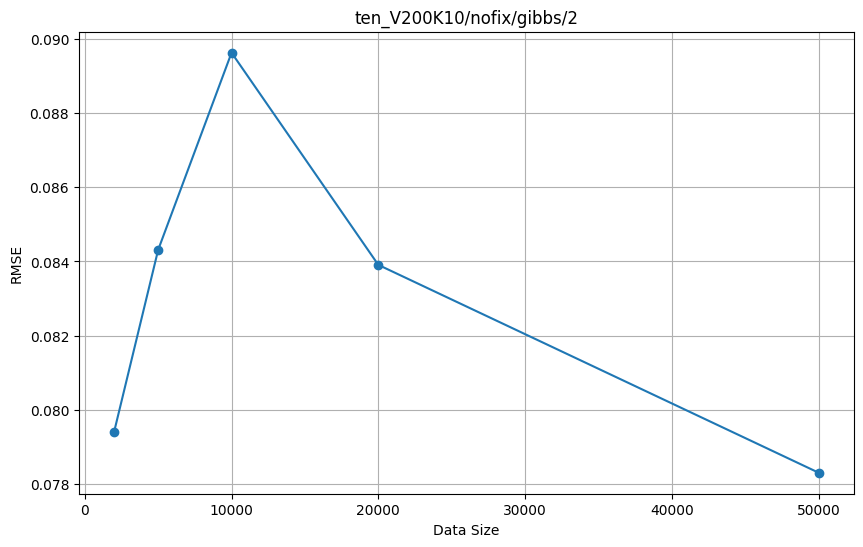

In [11]:
# --- PLOT ONE CONVERGENCE ---

i = str(2)
saved_fits_dir = "stan_fits_dxdfixmap"#"stan_fits_mfvi_dxd"#"stan_fits_dxdfixmap" "stan_fit_nofix" "stan_fits_frvi_dxd" stan_fits_map
saved_fits_dir = "ten_V100K5/nofix/vi/" + i
saved_fits_dir = "ten_V200K10/nofix/gibbs/" + i
#saved_fits_dir = "ten_2d_datasets/hmc/" + i
#stan_fits_dxd_mapfit is OUTDATED use instead stan_fits_dxd_mapjacobian :: CORRECTION, turns out they are the same..
# stan_fits_laplacedxd
inference_method = 'gibbs'
sizes = [100, 200, 500, 1000, 5000, 10000, 20000, 50000, 100000]
sizes = [2000, 5000, 10000, 20000, 50000]

data_path = "ten_V100K5/%s.json"%i #'100k_v10_d2_.json'
data_path = "ten_V200K10/%s.json"%i #'100k_v10_d2_.json'
#data_path = "ten_2d_datasets/%s.json"%i
#data_path = '100k_v10_d2_.json'
# -- true parameters --
with open(data_path) as f:
    data = json.load(f)
true_theta = np.array(data['theta'])
vocabulary = data['vocabulary']

rmse_scores = []

for size in sizes:
    print(size)
    if inference_method=='laplace': #just book keeping. Save map fits seperately when doing laplace
        fit = load_fit(f'map_{size}', saved_fits_dir)
    elif inference_method=='gibbs':
        pass
    else:
        fit = load_fit(size, saved_fits_dir)

    # here we extract word and context vectors based on inference method
    if inference_method == 'hmc':
        estimated_word_vectors = fit['word_vectors']
        estimated_context_vectors = fit['context_vectors']
        num_samples = estimated_word_vectors.shape[2]
            
    elif inference_method == 'vi':
        #variational_params = fit.variational_sample
        estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.variational_sample_pd, vocabulary)
        num_samples = estimated_word_vectors.shape[2]
    elif inference_method in ('map', 'laplace'):
        estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.optimized_params_pd, vocabulary)
        num_samples = 1
    elif inference_method == 'gibbs':
        filepath = saved_fits_dir + f'/gibbs-samples-N-{size}.csv'
        estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_gibbs(filepath, vocabulary)
        num_samples = estimated_word_vectors.shape[2]

    """
    print('loaded now appending')
    theta_samples = []
    for i in range(num_samples):
        word_vectors = estimated_word_vectors[:, :, i]
        context_vectors = estimated_context_vectors[:, :, i]
        theta = np.vstack((word_vectors, context_vectors))
        theta_samples.append(theta)
    """

    theta_combined = np.concatenate((estimated_word_vectors, estimated_context_vectors), axis=0)
    theta_samples = np.moveaxis(theta_combined, 2, 0)

    print('now rmse..')
    rmse = calculate_rmse(theta_samples, true_theta, vocabulary)
    rmse_scores.append(rmse)
    print(f"Size: {size}, RMSE: {rmse}")

# Plot RMSE vs. Size
plt.figure(figsize=(10, 6))
plt.plot(sizes, rmse_scores, marker='o')
plt.xlabel('Data Size')
plt.ylabel('RMSE')
plt.title(f'{saved_fits_dir}')
#plt.xscale('log')
plt.grid(True)
plt.show()


using data:  ten_V100K5/1.json
Processing folder 1, size 1000
Folder: 1, Size: 1000, RMSE: 0.10588059845582798
Processing folder 1, size 5000
Folder: 1, Size: 5000, RMSE: 0.10547036906137432
Processing folder 1, size 10000
Folder: 1, Size: 10000, RMSE: 0.10610906031597604
Processing folder 1, size 20000
Folder: 1, Size: 20000, RMSE: 0.10116077055938473
Processing folder 1, size 50000
Folder: 1, Size: 50000, RMSE: 0.09618610568730952
Processing folder 1, size 100000
Folder: 1, Size: 100000, RMSE: 0.09248354070826628
Processing folder 1, size 500000
Folder: 1, Size: 500000, RMSE: 0.08894850142888472
Processing folder 1, size 1000000
Folder: 1, Size: 1000000, RMSE: 0.07717235947818642
using data:  ten_V100K5/1.json
Processing folder 2, size 1000
Folder: 2, Size: 1000, RMSE: 0.10588821179915256
Processing folder 2, size 5000
Folder: 2, Size: 5000, RMSE: 0.10593805799039066
Processing folder 2, size 10000
Folder: 2, Size: 10000, RMSE: 0.105044290583758
Processing folder 2, size 20000
Folder

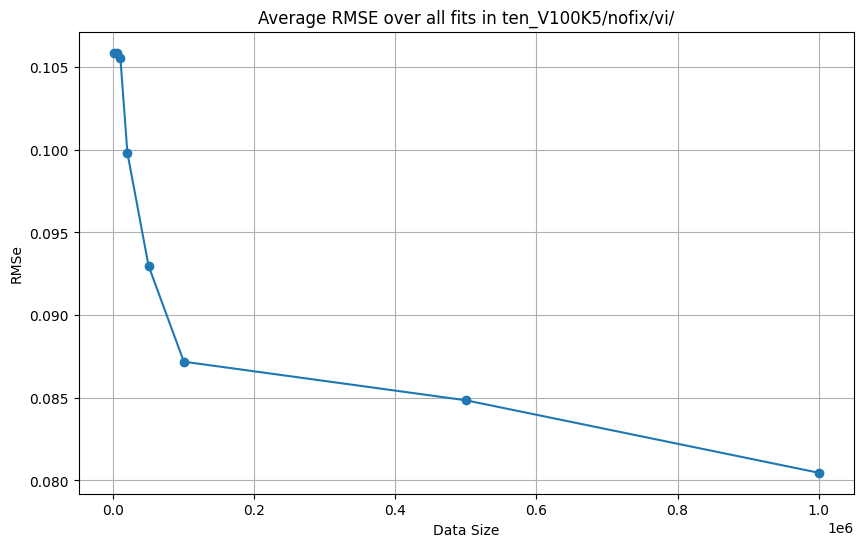

In [27]:
# ----  CONVERGENCE AVERAGE ALL FITS ------
base_dir = "ten_V100K5/nofix/vi/"
folders = [str(i) for i in range(1, 11)]  # Example: assuming folders are named "1" to "10"
folders = [str(i) for i in [1,2,3,4,5,6,7]] #7,8, 9 , 10
inference_method = 'vi'
#sizes = [100, 200, 500, 1000, 5000, 10000, 20000, 50000, 100000]
#sizes = [2000, 5000, 10000, 20000, 50000]
sizes = [1000, 5000, 10000, 20000, 50000, 100000, 500000, 1000000]

rmse_scores_per_size = {size: [] for size in sizes}


for i in folders:
    saved_fits_dir = os.path.join(base_dir, i)
    data_path = f"ten_V100K5/{1}.json"
    print('using data: ', data_path)
    
    # load the true parameters
    with open(data_path) as f:
        data = json.load(f)
    true_theta = np.array(data['theta'])
    vocabulary = data['vocabulary']
    
    # calculate rmse for each size.
    for size in sizes:
        print(f"Processing folder {i}, size {size}")
        
        # Load the fit based on the inference method
        if inference_method == 'laplace':
            fit = load_fit(f'map_{size}', saved_fits_dir)
        elif inference_method=='gibbs':
            pass
        else:
            fit = load_fit(size, saved_fits_dir)

        # here we extract word and context vectors based on inference method
        if inference_method == 'hmc':
            estimated_word_vectors = fit['word_vectors']
            estimated_context_vectors = fit['context_vectors']
            num_samples = estimated_word_vectors.shape[2]
        elif inference_method == 'vi':
            estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.variational_sample_pd, vocabulary)
            num_samples = estimated_word_vectors.shape[2]
        elif inference_method in ('map', 'laplace'):
            estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.optimized_params_pd, vocabulary)
            num_samples = 1
        elif inference_method == 'gibbs':
            filepath = saved_fits_dir + f'/gibbs-samples-N-{size}.csv'
            estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_gibbs(filepath, vocabulary)
            num_samples = estimated_word_vectors.shape[2]


        # combine and reshape theta samples
        theta_combined = np.concatenate((estimated_word_vectors, estimated_context_vectors), axis=0)
        theta_samples = np.moveaxis(theta_combined, 2, 0)

        # calc RMSe
        rmse = calculate_rmse(theta_samples, true_theta, vocabulary)
        rmse_scores_per_size[size].append(rmse)
        print(f"Folder: {i}, Size: {size}, RMSE: {rmse}")


average_rmse_scores = [np.mean(rmse_scores_per_size[size]) for size in sizes]


plt.figure(figsize=(10, 6))
plt.plot(sizes, average_rmse_scores, marker='o')
plt.xlabel('Data Size')
plt.ylabel('RMSe')
plt.title(f'Average RMSE over all fits in {base_dir}')
# plt.xscale('log')
plt.grid(True)
plt.show()

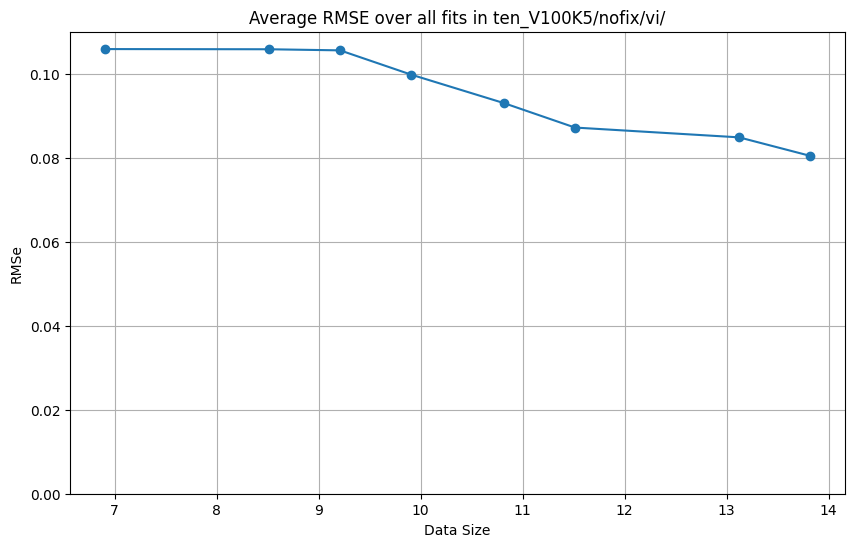

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(np.log(sizes), average_rmse_scores, marker='o')
plt.xlabel('Data Size')
plt.ylabel('RMSe')
plt.title(f'Average RMSE over all fits in {base_dir}')
# plt.xscale('log')
plt.grid(True)
plt.ylim((0,0.11))
plt.show()

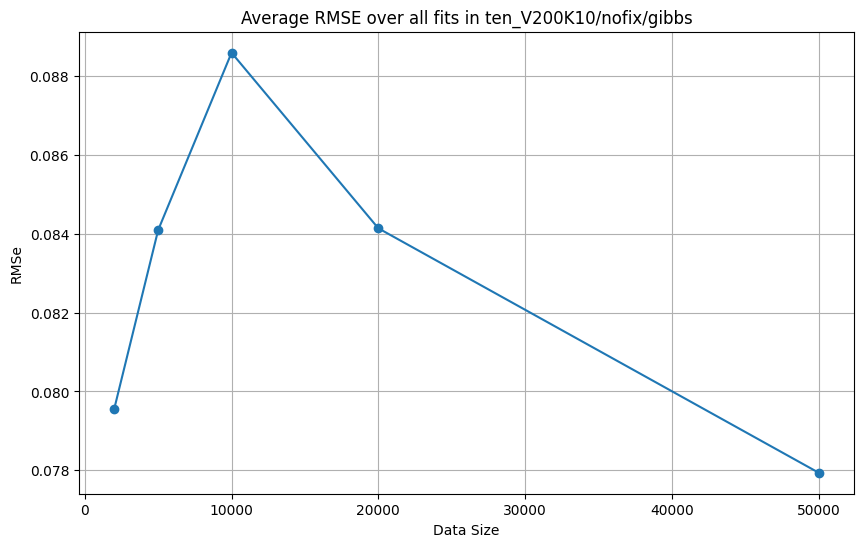

In [18]:

plt.figure(figsize=(10, 6))
plt.plot(sizes, average_rmse_scores, marker='o')
plt.xlabel('Data Size')
plt.ylabel('RMSe')
plt.title(f'Average RMSE over all fits in {base_dir}')
# plt.xscale('log')
plt.grid(True)
plt.show()

In [7]:
type(theta_samples)

list

In [6]:
vocabulary

{'word0': 0,
 'word1': 1,
 'word2': 2,
 'word3': 3,
 'word4': 4,
 'word5': 5,
 'word6': 6,
 'word7': 7,
 'word8': 8,
 'word9': 9,
 'word10': 10,
 'word11': 11,
 'word12': 12,
 'word13': 13,
 'word14': 14,
 'word15': 15,
 'word16': 16,
 'word17': 17,
 'word18': 18,
 'word19': 19,
 'word20': 20,
 'word21': 21,
 'word22': 22,
 'word23': 23,
 'word24': 24,
 'word25': 25,
 'word26': 26,
 'word27': 27,
 'word28': 28,
 'word29': 29,
 'word30': 30,
 'word31': 31,
 'word32': 32,
 'word33': 33,
 'word34': 34,
 'word35': 35,
 'word36': 36,
 'word37': 37,
 'word38': 38,
 'word39': 39,
 'word40': 40,
 'word41': 41,
 'word42': 42,
 'word43': 43,
 'word44': 44,
 'word45': 45,
 'word46': 46,
 'word47': 47,
 'word48': 48,
 'word49': 49,
 'word50': 50,
 'word51': 51,
 'word52': 52,
 'word53': 53,
 'word54': 54,
 'word55': 55,
 'word56': 56,
 'word57': 57,
 'word58': 58,
 'word59': 59,
 'word60': 60,
 'word61': 61,
 'word62': 62,
 'word63': 63,
 'word64': 64,
 'word65': 65,
 'word66': 66,
 'word67': 67,


In [7]:
np.shape(true_theta)

(200, 5)

In [8]:
np.shape(theta_samples)

(20000, 200, 5)

In [8]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def calculate_eta(vi, wi, theta, V):
    rho_v = theta[vi, :]          # ρ_v = θ_v
    alpha_w = theta[wi + V, :]    # α_w = θ_{V + w}
    eta = rho_v.dot(alpha_w)      # η = ρ_v^T α_w
    return eta

def calculate_p(vi, wi, theta, V):
    eta = calculate_eta(vi, wi, theta, V)
    return sigmoid(eta)

def load_fit(size, save_dir):
    filename = os.path.join(save_dir, f'stan_fit_{size}.pkl')
    with open(filename, 'rb') as f:
        fit = pickle.load(f)
    return fit

def calculate_rmse(theta_samples, true_theta, vocabulary):
    V = len(vocabulary)
    
    p_true = []
    p_avg = []

    for word1 in vocabulary:
        for word2 in vocabulary:
            vi = vocabulary[word1]
            wi = vocabulary[word2]
            p_true.append(calculate_p(vi, wi, true_theta, V))

            p_samples = [calculate_p(vi, wi, theta, V) for theta in theta_samples]
            p_avg.append(np.mean(p_samples))
    
    p_true = np.array(p_true)
    p_avg = np.array(p_avg)
    
    rmse = np.sqrt(np.mean((p_true - p_avg) ** 2))
    return rmse


rmse = calculate_rmse(theta_samples, true_theta, vocabulary)

1000

In [121]:
fit.optimized_params_pd[['context_vectors[1,1]', 'context_vectors[1,2]']]

,"context_vectors[1,1]","context_vectors[1,2]"
0,0.067889,-0.057962


In [15]:
rmse_scores

[0.12572098966136888,
 0.11933171301304289,
 0.10132137385759758,
 0.08863111248403835,
 0.058775025405132325,
 0.03271509446487707,
 0.022812635726706543,
 0.013848799579946294,
 0.010631243055074886]

In [12]:
len(rmse_scores)

8

VI
HMC
MAP
Gibbs


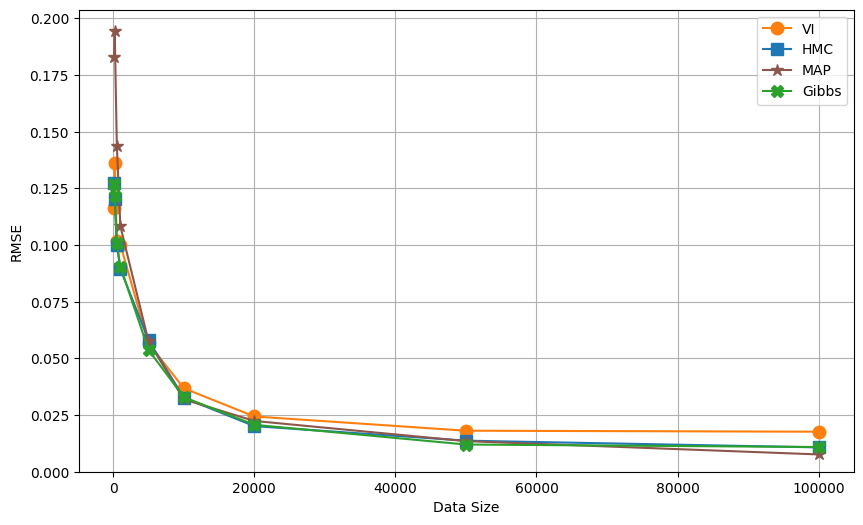

In [24]:
plot_dict = {}

mfvi_dxd = [0.11632057101585079,
 0.13617879109552525,
 0.1018288461556234,
 0.10022146072348655,
 0.05663176971699401,
 0.0368225, 
 0.024384621160304536,
 0.018095653760013868,
 0.017659300187553937]

hmc_dxd = \
[0.12726307352897834,
 0.12033065444990518,
 0.09987843908704594,
 0.08946308659166671,
 0.05796288507616593,
 0.03264020114,
 0.020115503262416252,
 0.013702870051998306,
 0.01074382506784676]

aggregated_hmc = \
[0.12572098966136888,
 0.11933171301304289,
 0.10132137385759758,
 0.08863111248403835,
 0.058775025405132325,
 0.03271509446487707,
 0.022812635726706543,
 0.013848799579946294,
 0.010631243055074886]

map_ = [0.1830949237042245,
 0.19450435084177722,
 0.13259847799247187,
 0.10837218811137438,
 0.0531530555547684,
 0.031893,
 0.01977160486911018,
 0.011878810380597932,
 0.007624994760738237]

map_dxd_outdated = [0.18309383124137898,
 0.19450767181911538,
 0.1326009555370244,
 0.10837730275860734,
 0.05746946626917002,
 0.03571879165622537,
 0.022393612608158923,
 0.01188889922157979,
 0.007610450784667295]

map_dxd = [0.18309419620920864,
 0.19450559919808896,
 0.14390799276624497,
 0.10837988209560422,
 0.057461396240282576,
 0.03190548343639432,
 0.022403710511344162,
 0.013495971230891081,
 0.007627481816835393] #corresponds to the laplace map, which in turn uses dxd fixed params from "original map"


gibbs_dxd = [0.127, 0.1215, 0.101, 0.0905, 0.0537, 0.0329, 0.0207, 0.012, 0.0109]


PLOT_KEYWORD = 'dxdfix' #nofix , dxdfix
plot_dict['VI'] = mfvi_dxd
plot_dict['HMC'] = hmc_dxd
plot_dict['MAP'] = map_dxd
plot_dict['Gibbs'] = gibbs_dxd

colors = {'VI': 'tab:orange', 'HMC': 'tab:blue', 'MAP': 'tab:brown', 'Gibbs': 'tab:green'}
markers = {'VI': 'o', 'HMC': 's', 'MAP': '*', 'Gibbs':'X'}
sizes = [100, 200, 500, 1000, 5000, 10000, 20000, 50000, 100000]


plt.figure(figsize=(10, 6))
for method, rmse in plot_dict.items():
    print(method)
    plt.plot(sizes, rmse, color=colors[method], label=method, marker=markers[method], markersize=9) #, marker='o'

# Plot RMSE vs. Size


plt.xlabel('Data Size')
plt.ylabel('RMSE')
#plt.title(f'{saved_fits_dir}')
#plt.xscale('log')
plt.legend()
#
plt.grid(True)

plt.rcParams.update({'font.size': 14})
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 18

#plt.yscale('log')
#plt.xscale('log')
plt.ylim((0,None))

plt.savefig(f'figs/convergence_{PLOT_KEYWORD}.pdf')
plt.show()


# Word Pair Convergence

colors:
- VI tab:blue
- hmc tab:brown
- laplace tab:orange
- gibbs tab: ?

In [18]:
import pandas as pd

x = pd.read_csv('gibbs-samples/gibbs-samples-N-20000.csv.fix')

x.columns

Index(['word0_0', 'word0_1', 'word0_c_0', 'word0_c_1', 'word1_0', 'word1_1',
       'word1_c_0', 'word1_c_1', 'word2_0', 'word2_1', 'word2_c_0',
       'word2_c_1', 'word3_0', 'word3_1', 'word3_c_0', 'word3_c_1', 'word4_0',
       'word4_1', 'word4_c_0', 'word4_c_1', 'word5_0', 'word5_1', 'word5_c_0',
       'word5_c_1', 'word6_0', 'word6_1', 'word6_c_0', 'word6_c_1', 'word7_0',
       'word7_1', 'word7_c_0', 'word7_c_1', 'word8_0', 'word8_1', 'word8_c_0',
       'word8_c_1', 'word9_0', 'word9_1', 'word9_c_0', 'word9_c_1'],
      dtype='object')

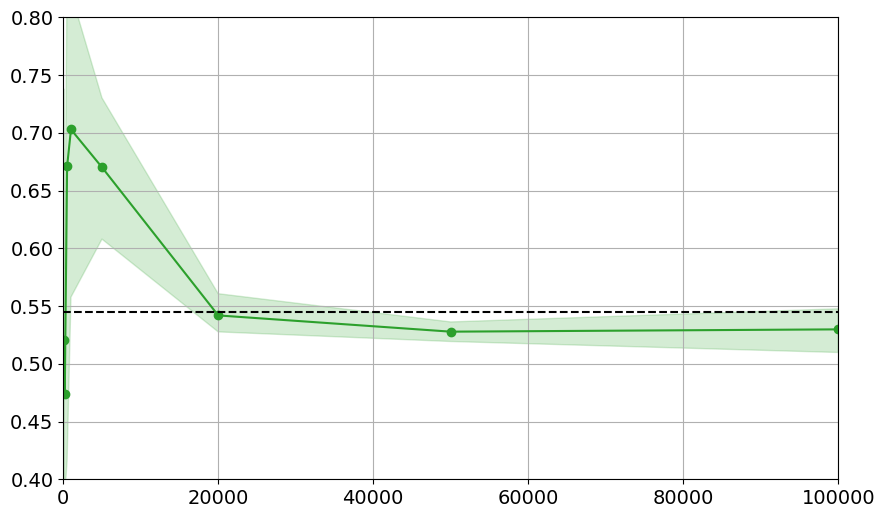

In [46]:
word1 = "word1"
word2 = "word0"

save_fig = False

sizes = [100, 200, 500, 1000, 5000, 20000, 50000, 100000]
saved_fits_dir = "gibbs-samples"#"stan_fits_dxdfixmap" # stan_fits_mfvi_nofix #stan_fit_nofix #stan_fits_laplacedxd #gibbs-samples #stan_fits_mfvi_dxd
inference_method = 'gibbs'


with open('100k_v10_d2_.json') as f:
    data = json.load(f)

true_theta = np.array(data['theta'])
vocabulary = data['vocabulary']

true_p = calculate_p(vocabulary[word1], vocabulary[word2], true_theta, len(vocabulary))

p_means = []
credible_intervals = []

for size in sizes:

    if not inference_method == 'gibbs':
        fit = load_fit(size, saved_fits_dir)

    if inference_method == 'hmc':
        estimated_word_vectors = fit['word_vectors']
        estimated_context_vectors = fit['context_vectors']
        num_samples = estimated_word_vectors.shape[2]
    elif inference_method == 'vi':
        estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.variational_sample_pd, vocabulary)
        num_samples = estimated_word_vectors.shape[2]
    elif inference_method in ('laplace', 'map'):
        estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.draws_pd(), vocabulary)
        num_samples = estimated_word_vectors.shape[2]
    elif inference_method == 'gibbs':
        filepath = saved_fits_dir + f'/gibbs-samples-N-{size}.csv.fix'
        estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_gibbs(filepath, vocabulary)
        num_samples = estimated_word_vectors.shape[2]

    theta_samples = []
    for i in range(num_samples):
        word_vectors = estimated_word_vectors[:, :, i]
        context_vectors = estimated_context_vectors[:, :, i]
        theta = np.vstack((word_vectors, context_vectors))
        theta_samples.append(theta)

    vi = vocabulary[word1]
    wi = vocabulary[word2]
    eta_samples = [calculate_p(vi, wi, theta, len(vocabulary)) for theta in theta_samples]

    mean_p = np.mean(eta_samples)
    lower_ci, upper_ci = credible_interval(eta_samples)

    p_means.append(mean_p)
    credible_intervals.append((lower_ci, upper_ci))


p_means = np.array(p_means)
credible_intervals = np.array(credible_intervals)

plt.figure(figsize=(10, 6))
plt.ylim([0.4, 0.8])
plt.plot(sizes, p_means, marker='o', linestyle='-', label='VI', color='tab:green')
plt.fill_between(sizes, credible_intervals[:, 0], credible_intervals[:, 1], color='tab:green', alpha=0.2, label='VI 90% CI')
plt.axhline(y=true_p, color='k', linestyle='--', label='True')
#plt.xlabel('Data Size')
#plt.ylabel('Co-occurrence probability')

#plt.title(f'{saved_fits_dir}: {word1} - {word2}')
#plt.legend()
plt.grid(True)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlim([0, 100000])

if save_fig:
    plt.savefig(f'figs/wordpair_{saved_fits_dir}_{word1}{word2}.pdf')

plt.show()

### # Coverage of similarities

data: 100, coverage: 92.22%
data: 200, coverage: 98.89%
data: 500, coverage: 93.33%
data: 1000, coverage: 91.11%
data: 5000, coverage: 83.33%
data: 20000, coverage: 88.89%
data: 50000, coverage: 90.00%
data: 100000, coverage: 91.11%


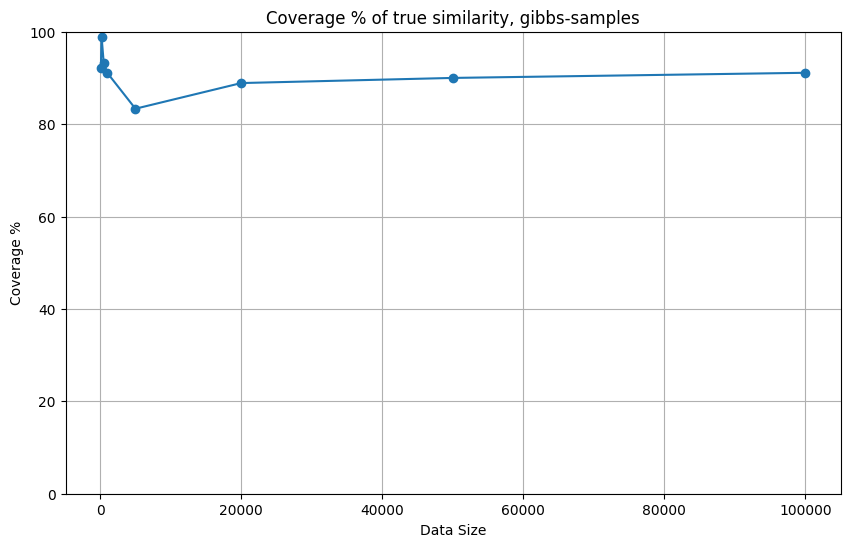

In [3]:



sizes = [100, 200, 500, 1000, 5000, 20000, 50000, 100000]
saved_fits_dir = "gibbs-samples"#"aggregated_test"#"stan_fits_dxdfixmap" # stan_fits_mfvi_nofix #stan_fit_nofix #stan_fits_laplacedxd #gibbs-samples #stan_fits_mfvi_dxd
inference_method = 'gibbs'#'hmc'


with open('100k_v10_d2_.json') as f:
    data = json.load(f)

true_theta = np.array(data['theta'])
vocabulary = data['vocabulary']

word_pairs = list(itertools.combinations(vocabulary, 2))
total_pairs = len(word_pairs) * 2

coverage_per_size = {}

for size in sizes:
    covered_count = 0
    
    if not inference_method == 'gibbs':
        fit = load_fit(size, saved_fits_dir)

    if inference_method == 'hmc':
        estimated_word_vectors = fit['word_vectors']
        estimated_context_vectors = fit['context_vectors']
        num_samples = estimated_word_vectors.shape[2]
    elif inference_method == 'vi':
        estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.variational_sample_pd, vocabulary)
        num_samples = estimated_word_vectors.shape[2]
    elif inference_method in ('laplace', 'map'):
        estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.draws_pd(), vocabulary)
        num_samples = estimated_word_vectors.shape[2]
    elif inference_method == 'gibbs':
        filepath = saved_fits_dir + f'/gibbs-samples-N-{size}.csv.fix'
        estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_gibbs(filepath, vocabulary)
        num_samples = estimated_word_vectors.shape[2]

    theta_samples = []
    for i in range(num_samples):
        word_vectors = estimated_word_vectors[:, :, i]
        context_vectors = estimated_context_vectors[:, :, i]
        theta = np.vstack((word_vectors, context_vectors))
        theta_samples.append(theta)

    for word1, word2 in word_pairs:
        vi = vocabulary[word1]
        wi = vocabulary[word2]
        true_p = calculate_p(vi, wi, true_theta, len(vocabulary))

        eta_samples = [calculate_p(vi, wi, theta, len(vocabulary)) for theta in theta_samples]
        lower_ci, upper_ci = credible_interval(eta_samples)

        if lower_ci <= true_p <= upper_ci:
            covered_count += 1

        true_p = calculate_p(wi, vi, true_theta, len(vocabulary))

        eta_samples = [calculate_p(wi, vi, theta, len(vocabulary)) for theta in theta_samples]
        lower_ci, upper_ci = credible_interval(eta_samples)

        if lower_ci <= true_p <= upper_ci:
            covered_count += 1

    coverage_percentage = (covered_count / total_pairs) * 100
    coverage_per_size[size] = coverage_percentage


for size, coverage in coverage_per_size.items():
    print(f"data: {size}, coverage: {coverage:.2f}%")

plt.figure(figsize=(10, 6))
plt.plot(sizes, [coverage_per_size[size] for size in sizes], marker='o', linestyle='-', color='tab:blue')
plt.xlabel('Data Size')
plt.ylabel('Coverage %')
plt.title(f'Coverage % of true similarity, {saved_fits_dir}')
plt.grid(True)
plt.ylim([0, 100])
#plt.savefig('figs/coverage_all_pairs.pdf')
plt.show()

In [48]:
x = np.array(list(coverage_per_size.values())).round(1)
x_arrstr = np.char.mod('%.1f', x)
' & '.join(x_arrstr)

'92.2 & 98.9 & 93.3 & 91.1 & 83.3 & 88.9 & 90.0 & 91.1'

# Coverage 10 repetitions

In [32]:
# Assume:
# - ten_2d_datasets contains datasets, ex: ten_2d_datasets/1.json
# - ten_2d_datasets/inference_method/1 are the fit folders

main_folder = 'ten_V100K5'#'ten_2d_datasets' 
saved_fit_folder = 'ten_V100K5/nofix/vi/'
data_folder = 'ten_V100K5'
inference_method = 'vi'
experiments_ids = [1,2,3]
sizes = [100, 200, 500, 1000, 5000, 20000, 50000, 100000]
sizes = [500000, 1000000]

coverage_per_size = {size: [] for size in sizes}

for size in sizes:
    print(f"Processing size {size}...")
    
    # Loop over experiment repetitions (1 to 10)
    for repetition in experiments_ids:
        covered_count = 0
        
        # data
        data_path = os.path.join(data_folder, f"{repetition}.json")
        with open(data_path) as f:
            data = json.load(f)

        true_theta = np.array(data['theta'])
        vocabulary = data['vocabulary']
        word_pairs = list(itertools.combinations(vocabulary, 2))
        total_pairs = len(word_pairs) * 2

        # inference fit path
        saved_fit_dir_i = os.path.join(saved_fit_folder, str(repetition))
        
        if not inference_method == 'gibbs':
            fit = load_fit(size, saved_fit_dir_i)
            
        if inference_method == 'hmc':
            estimated_word_vectors = fit['word_vectors']
            estimated_context_vectors = fit['context_vectors']
            num_samples = estimated_word_vectors.shape[2]
        elif inference_method == 'vi':
            estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.variational_sample_pd, vocabulary)
            num_samples = estimated_word_vectors.shape[2]
        elif inference_method in ('laplace', 'map'):
            estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.draws_pd(), vocabulary)
            num_samples = estimated_word_vectors.shape[2]
        elif inference_method == 'gibbs':
            filepath = os.path.join(saved_fit_dir_i, f'gibbs-samples-N-{size}.csv.fix')
            estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_gibbs(filepath, vocabulary)
            num_samples = estimated_word_vectors.shape[2]

        theta_samples = []
        for i in range(num_samples):
            word_vectors = estimated_word_vectors[:, :, i]
            context_vectors = estimated_context_vectors[:, :, i]
            theta = np.vstack((word_vectors, context_vectors))
            theta_samples.append(theta)

        # Loop through word pairs and compute coverage
        for word1, word2 in word_pairs:
            vi = vocabulary[word1]
            wi = vocabulary[word2]
            true_p = calculate_p(vi, wi, true_theta, len(vocabulary))

            eta_samples = [calculate_p(vi, wi, theta, len(vocabulary)) for theta in theta_samples]
            lower_ci, upper_ci = credible_interval(eta_samples)

            if lower_ci <= true_p <= upper_ci:
                covered_count += 1

            true_p = calculate_p(wi, vi, true_theta, len(vocabulary))

            eta_samples = [calculate_p(wi, vi, theta, len(vocabulary)) for theta in theta_samples]
            lower_ci, upper_ci = credible_interval(eta_samples)

            if lower_ci <= true_p <= upper_ci:
                covered_count += 1

        coverage_percentage = (covered_count / total_pairs) * 100
        coverage_per_size[size].append(coverage_percentage)

# Average the coverage for each size
average_coverage_per_size = {size: np.mean(coverage_per_size[size]) for size in sizes}


coverage_stats_per_size = {}
for size in sizes:
    coverage_list = coverage_per_size[size]
    mean_coverage = np.mean(coverage_list)
    std_coverage = np.std(coverage_list)  # Standard deviation
    sem_coverage = std_coverage / np.sqrt(len(coverage_list))  # SEM
    coverage_stats_per_size[size] = {'mean': mean_coverage, 'std': std_coverage, 'sem': sem_coverage}


for size, stats in coverage_stats_per_size.items():
    print(f"Data size: {size}, Average coverage: {stats['mean']:.2f}%, ± {stats['std']:.2f}% (std), ± {stats['sem']:.2f}% (SEM)")

# Output the average coverage results
#for size, coverage in average_coverage_per_size.items():
#    print(f"Data size: {size}, Average coverage: {coverage:.2f}%")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(sizes, [average_coverage_per_size[size] for size in sizes], marker='o', linestyle='-', color='tab:blue')
plt.xlabel('Data Size')
plt.ylabel('Coverage %')
plt.title(f'Average Coverage % of True Similarity, {saved_fits_dir}')
plt.grid(True)
plt.ylim([0, 100])
plt.show()

Processing size 500000...
Processing size 10000000...


FileNotFoundError: [Errno 2] No such file or directory: 'ten_V100K5/nofix/vi/1/stan_fit_10000000.pkl'

In [11]:
x = np.array(list(average_coverage_per_size.values())).round(1)
x_arrstr = np.char.mod('%.1f', x)
' & '.join(x_arrstr)

'93.0 & 88.4 & 91.3 & 92.0 & 90.2 & 87.8 & 85.7 & 86.2'

# "Donut" Plot

FileNotFoundError: [Errno 2] No such file or directory: 'figs/donut_ten_2d_datasets/hmc/1_wordidx0.pdf'

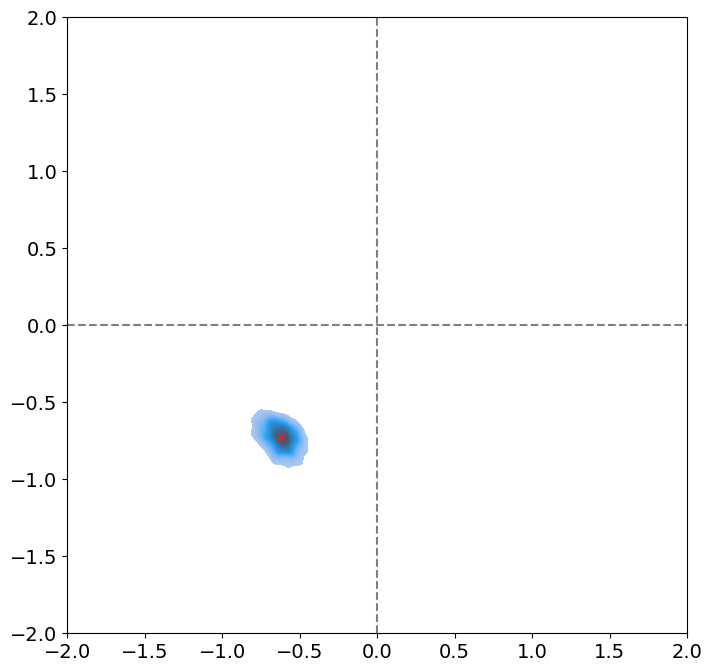

In [16]:
import seaborn as sns
import pandas as pd

word_index = 0

i = str(1)
data_path = '100k_v10_d2_.json' #"ten_2d_datasets/%s.json"%i #100k_v10_d2_.json'
with open('100k_v10_d2_.json') as f:
    data = json.load(f)



vocabulary = data['vocabulary']

# --  specify fit ---
inference_method = 'hmc' 
size = 50000
#saved_fits_dir = "stan_fits_dxdfixmap" #"stan_fits_mfvi_dxd" #"stan_fits_dxdfixmap" stan_fit_nofix
#saved_fits_dir = "ten_2d_datasets/hmc/%s"%i
fit = load_fit(size, saved_fits_dir)

if inference_method == 'hmc':
    word_vectors_samples = fit['word_vectors']
    #context_vectors_samples = fit['context_vectors']
elif inference_method == 'vi':
    word_vectors_samples, _ = extract_word_and_context_vectors_vi(fit, vocabulary)
# ----

#def plot_posterior(word_index, word_vectors_samples, vocabulary):
word_samples = word_vectors_samples[word_index]

data = {
    'Dim 1': word_samples[0, :],
    'Dim 2': word_samples[1, :],
}
df = pd.DataFrame(data)

plt.figure(figsize=(8, 8))
sns.kdeplot(x='Dim 1', y='Dim 2', data=df, fill=True, thresh=0.05, levels=100) # cmap='Blues'
#sns.jointplot(x='Dim 1', y='Dim 2', data=df, kind='kde', fill=True)

#plt.title(f"{saved_fits_dir} post samples for '{list(vocabulary.keys())[word_index]}'")
plt.scatter([np.mean(word_samples[0, :])], [np.mean(word_samples[1, :])], marker='x', color='tab:red')
plt.axhline(y=0, color='tab:gray', ls='--')
plt.axvline(x=0, color='tab:gray', ls='--')
plt.xlim([-2, 2])
plt.ylim([-2, 2])


plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel('')
plt.ylabel('')


plt.savefig(f'figs/donut_{saved_fits_dir}_wordidx{word_index}.pdf')

plt.show()



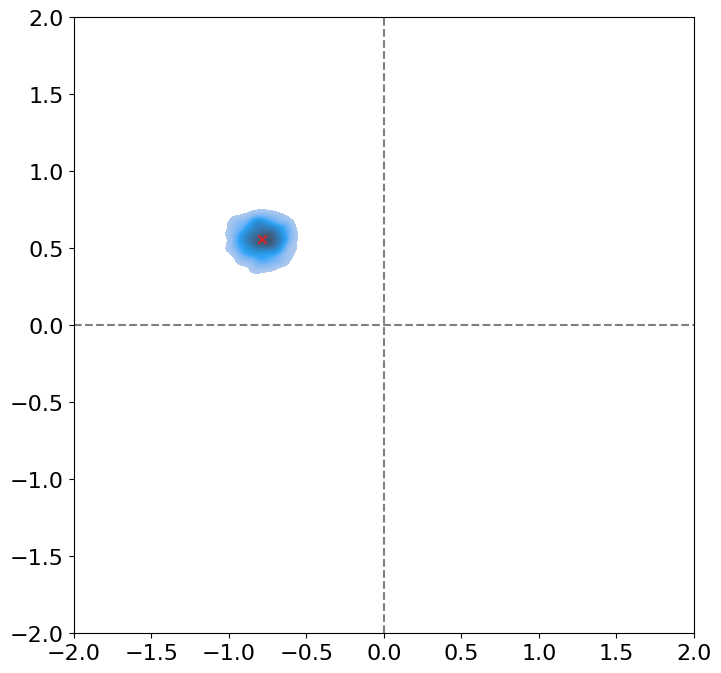

In [143]:
import seaborn as sns
import pandas as pd


with open('100k_v10_d2_.json') as f:
    data = json.load(f)

vocabulary = data['vocabulary']

# --  specify fit ---
inference_method = 'vi' 
saved_fits_dir = "stan_fits_mfvi_dxd" #"stan_fits_mfvi_dxd" #"stan_fits_dxdfixmap" #stan_fits_mfvi_nofix
fit = load_fit(size, saved_fits_dir)

if inference_method == 'hmc':
    word_vectors_samples = fit['word_vectors']
    #context_vectors_samples = fit['context_vectors']
elif inference_method == 'vi':
    word_vectors_samples, _ = extract_word_and_context_vectors_vi(fit.variational_sample_pd, vocabulary)
# ----

#def plot_posterior(word_index, word_vectors_samples, vocabulary):
word_samples = word_vectors_samples[word_index]

data = {
    'Dim 1': word_samples[0, :],
    'Dim 2': word_samples[1, :],
}
df = pd.DataFrame(data)

plt.figure(figsize=(8, 8))
sns.kdeplot(x='Dim 1', y='Dim 2', data=df, fill=True, thresh=0.05, levels=100) # cmap='Blues'
#sns.jointplot(x='Dim 1', y='Dim 2', data=df, kind='kde', fill=True)

#plt.title(f"{saved_fits_dir} post samples for '{list(vocabulary.keys())[word_index]}'")
plt.scatter([np.mean(word_samples[0, :])], [np.mean(word_samples[1, :])], marker='x', color='tab:red')
plt.axhline(y=0, color='tab:gray', ls='--')
plt.axvline(x=0, color='tab:gray', ls='--')
plt.xlim([-2, 2])
plt.ylim([-2, 2])


plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel('')
plt.ylabel('')


plt.savefig(f'figs/donut_{saved_fits_dir}_wordidx{word_index}.pdf')

plt.show()



plt.show()

# Compare Donut

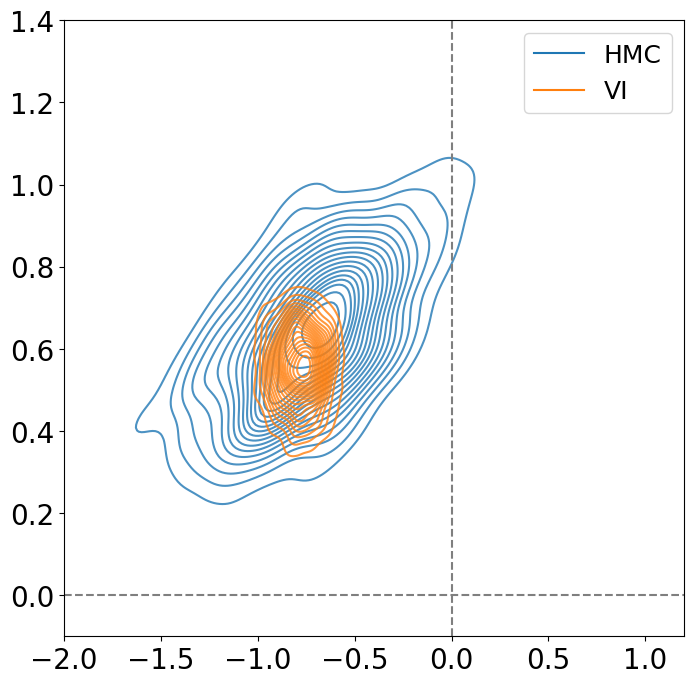

In [144]:
import json
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

word_index = 0

with open('100k_v10_d2_.json') as f:
    data = json.load(f)

vocabulary = data['vocabulary']

# -- specify fit for HMC ---
inference_method_hmc = 'hmc'
size = 20000
saved_fits_dir_hmc = "stan_fits_dxdfixmap"
fit_hmc = load_fit(size, saved_fits_dir_hmc)

word_vectors_samples_hmc = fit_hmc['word_vectors']

# -- specify fit for VI ---
inference_method_vi = 'vi'
saved_fits_dir_vi = "stan_fits_mfvi_dxd"
fit_vi = load_fit(size, saved_fits_dir_vi)

word_vectors_samples_vi, context_vectors_samples_vi = extract_word_and_context_vectors_vi(fit_vi.variational_sample_pd, vocabulary)

# ----

word_samples_hmc = word_vectors_samples_hmc[word_index]
word_samples_vi = word_vectors_samples_vi[word_index]

data_hmc = {
    'Dim 1': word_samples_hmc[0, :],
    'Dim 2': word_samples_hmc[1, :],
    'Method': ['HMC'] * word_samples_hmc.shape[1]
}

data_vi = {
    'Dim 1': word_samples_vi[0, :],
    'Dim 2': word_samples_vi[1, :],
    'Method': ['VI'] * word_samples_vi.shape[1]
}

df_hmc = pd.DataFrame(data_hmc)
df_vi = pd.DataFrame(data_vi)

df_combined = pd.concat([df_hmc, df_vi])

plt.figure(figsize=(8, 8))
sns.kdeplot(x='Dim 1', y='Dim 2', data=df_combined[df_combined['Method'] == 'HMC'], fill=False, thresh=0.05, levels=20, alpha=0.8, label='HMC')
sns.kdeplot(x='Dim 1', y='Dim 2', data=df_combined[df_combined['Method'] == 'VI'], fill=False, thresh=0.05, levels=20, alpha=0.8, label='VI')

# legend hack
plt.plot([], [], label='HMC', color='tab:blue')
plt.plot([], [], label='VI', color='tab:orange')

#plt.scatter([np.mean(word_samples_hmc[0, :])], [np.mean(word_samples_hmc[1, :])], marker='x', color='tab:blue', label='Mean HMC')
#plt.scatter([np.mean(word_samples_vi[0, :])], [np.mean(word_samples_vi[1, :])], marker='x', color='tab:orange', label='Mean VI')

plt.axhline(y=0, color='tab:gray', ls='--')
plt.axvline(x=0, color='tab:gray', ls='--')
#plt.xlim([-2, 2])
#plt.ylim([-2, 2])
plt.xlim([-2, 1.2])
plt.ylim([-0.1, 1.4])

plt.tick_params(axis='both', which='major', labelsize=20)
plt.xlabel('')
plt.ylabel('')

plt.legend()
plt.savefig(f'figs/combined_filled_donut_wordidx{word_index}.pdf')

plt.show()


In [129]:
def extract_word_and_context_vectors_gibbs(filepath, vocabulary, D=2):
    df = pd.read_csv(filepath).iloc[500:]
    print(len(df))
    num_samples = df.shape[0]
    V = len(vocabulary)
    
    word_vectors = np.zeros((V, D, num_samples))
    context_vectors = np.zeros((V, D, num_samples))
    
    for n in range(V):
        for d in range(D):
            word_vectors[n, d, :] = df[f'word{n}_{d}'].values
            context_vectors[n, d, :] = df[f'word{n}_c_{d}'].values
            print(n,d)
    return word_vectors, context_vectors

1496
0 0
0 1
1 0
1 1
2 0
2 1
3 0
3 1
4 0
4 1
5 0
5 1
6 0
6 1
7 0
7 1
8 0
8 1
9 0
9 1


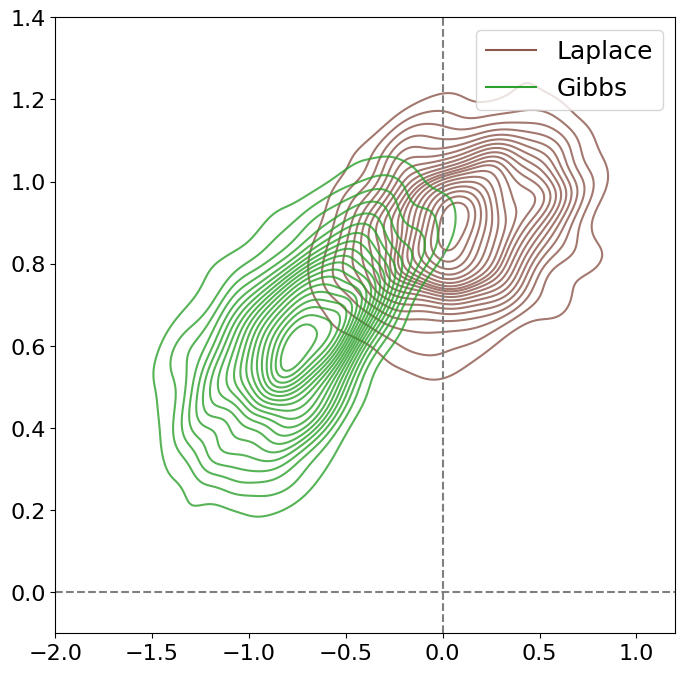

In [141]:

word_index = 0

with open('100k_v10_d2_.json') as f:
    data = json.load(f)

vocabulary = data['vocabulary']

# -- specify fit for Laplace ---
size = 20000
saved_fits_dir_laplace = "stan_fits_laplacedxd"
fit_laplace = load_fit(size, saved_fits_dir_laplace)
word_vectors_samples_laplace, context_vectors_samples_laplace = extract_word_and_context_vectors_vi(fit_laplace.draws_pd(), vocabulary)

# -- specify samples for Gibbs ---
file_path_gibbs = f'gibbs-samples/gibbs-samples-N-{size}.csv.fix'
word_vectors_samples_gibbs, context_vectors_samples_gibbs = extract_word_and_context_vectors_gibbs(file_path_gibbs, vocabulary)

# ----

word_samples_laplace = word_vectors_samples_laplace[word_index]
word_samples_gibbs = word_vectors_samples_gibbs[word_index]

data_laplace = {
    'Dim 1': word_samples_laplace[0, :],
    'Dim 2': word_samples_laplace[1, :],
    'Method': ['Laplace'] * word_samples_laplace.shape[1]
}

data_gibbs = {
    'Dim 1': word_samples_gibbs[0, :],
    'Dim 2': word_samples_gibbs[1, :],
    'Method': ['Gibbs'] * word_samples_gibbs.shape[1]
}

df_laplace = pd.DataFrame(data_laplace)
df_gibbs = pd.DataFrame(data_gibbs)

df_combined = pd.concat([df_laplace, df_gibbs])

plt.figure(figsize=(8, 8))
sns.kdeplot(x='Dim 1', y='Dim 2', data=df_combined[df_combined['Method'] == 'Laplace'], fill=False, thresh=0.05, levels=20, alpha=0.8, label='Laplace', color='tab:brown')
sns.kdeplot(x='Dim 1', y='Dim 2', data=df_combined[df_combined['Method'] == 'Gibbs'], fill=False, thresh=0.05, levels=20, alpha=0.8, label='Gibbs', color='tab:green')

plt.plot([], [], label='Laplace', color='tab:brown')
plt.plot([], [], label='Gibbs', color='tab:green')

plt.axhline(y=0, color='tab:gray', ls='--')
plt.axvline(x=0, color='tab:gray', ls='--')
plt.xlim([-2, 1.2])
plt.ylim([-0.1, 1.4])

plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel('')
plt.ylabel('')

plt.legend()
plt.savefig(f'figs/combined_gibbslaplace_donut_wordidx{word_index}.pdf')

plt.show()


# alpha^T rho

# ESS and R-hat

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)
arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)
arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)
arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)
arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)
arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)
arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)
arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


data: 100, median ESS: 662.00
data: 200, median ESS: 321.00
data: 500, median ESS: 295.50
data: 1000, median ESS: 404.50
data: 5000, median ESS: 505.50
data: 20000, median ESS: 269.00
data: 50000, median ESS: 183.00
data: 100000, median ESS: 206.50


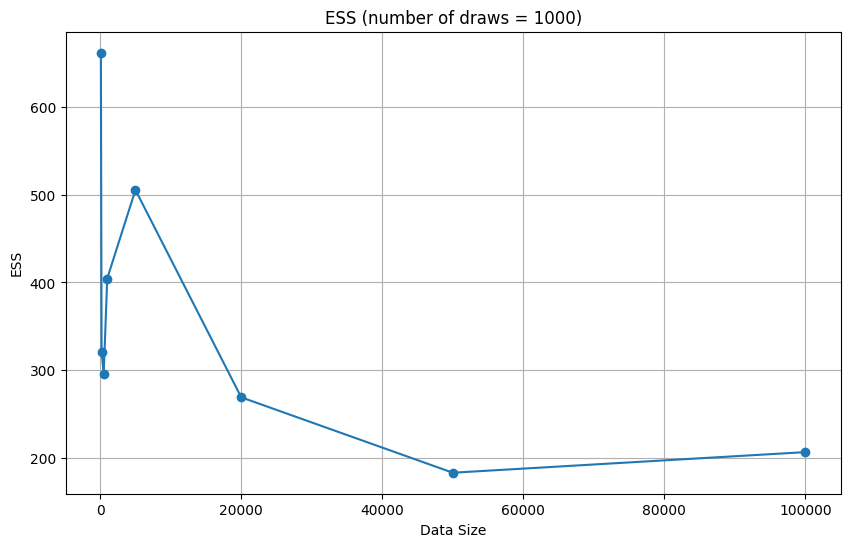

In [10]:



sizes = [100, 200, 500, 1000, 5000, 20000, 50000, 100000]
saved_fits_dir = "stan_fits_dxdfixmap"#"aggregated_test"#"stan_fits_dxdfixmap" # stan_fits_mfvi_nofix #stan_fit_nofix #stan_fits_laplacedxd #gibbs-samples #stan_fits_mfvi_dxd
#inference_method = 'gibbs'#'hmc'


with open('100k_v10_d2_.json') as f:
    data = json.load(f)

true_theta = np.array(data['theta'])
vocabulary = data['vocabulary']

word_pairs = list(itertools.combinations(vocabulary, 2))
total_pairs = len(word_pairs) * 2

ess_per_size = {}

for size in sizes:
    covered_count = 0
    
    #if not inference_method == 'gibbs': 
    fit = load_fit(size, saved_fits_dir)
    
    
    ess_per_size[size] = np.median(az.summary(fit).iloc[4:]['ess_bulk'])


for size, ess in ess_per_size.items():
    print(f"data: {size}, median ESS: {ess:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(sizes, [ess_per_size[size] for size in sizes], marker='o', linestyle='-', color='tab:blue')
plt.xlabel('Data Size')
plt.ylabel('ESS')
plt.title(f'ESS (number of draws = {fit.num_samples})')
plt.grid(True)
#plt.ylim([0, 100])
#plt.savefig('figs/coverage_all_pairs.pdf')
plt.show()

In [11]:
x = np.array(list(ess_per_size.values())).round(1)
x_arrstr = np.char.mod('%.1f', x)
' & '.join(x_arrstr)

'662.0 & 321.0 & 295.5 & 404.5 & 505.5 & 269.0 & 183.0 & 206.5'

In [3]:
def load_fit(size, save_dir):
    filename = os.path.join(save_dir, f'stan_fit_{size}.pkl')
    with open(filename, 'rb') as f:
        fit = pickle.load(f)
    return fit


fit_dir = 'stan_fits_dxdfixmap' #'ten_2d_datasets/hmc/1'
fit = load_fit(10000, fit_dir)

az.summary(fit).iloc[4:]

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"context_vectors[2, 0]",0.962,0.309,0.387,1.569,0.015,0.011,423.0,357.0,NaN
"context_vectors[2, 1]",1.073,0.306,0.571,1.678,0.018,0.013,298.0,363.0,NaN
"context_vectors[3, 0]",-0.111,0.148,-0.408,0.143,0.008,0.006,369.0,355.0,NaN
"context_vectors[3, 1]",0.192,0.119,-0.044,0.401,0.006,0.005,354.0,657.0,NaN
"context_vectors[4, 0]",0.078,0.133,-0.151,0.326,0.007,0.005,506.0,465.0,NaN
"context_vectors[4, 1]",-0.115,0.121,-0.338,0.091,0.005,0.004,597.0,616.0,NaN
"context_vectors[5, 0]",-1.081,0.365,-1.704,-0.449,0.029,0.020,168.0,240.0,NaN
"context_vectors[5, 1]",0.355,0.404,-0.450,1.042,0.034,0.024,141.0,282.0,NaN
"context_vectors[6, 0]",0.444,0.328,-0.087,1.075,0.026,0.019,165.0,310.0,NaN
"context_vectors[6, 1]",-0.845,0.300,-1.426,-0.296,0.024,0.017,144.0,370.0,NaN


In [7]:
fit.num_samples

1000

In [13]:
pip install arviz

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
fit

<stan.Fit>
Parameters:
    word_vectors: (10, 2)
    context_vectors_raw: (8, 2)
    context_vectors: (10, 2)
Draws: 1000

In [133]:
context_vectors_samples_gibbs[1]

array([[-0.206421, -0.206421, -0.206421, ..., -0.206421, -0.206421,
        -0.206421],
       [ 0.72608 ,  0.72608 ,  0.72608 , ...,  0.72608 ,  0.72608 ,
         0.72608 ]])

In [134]:
context_vectors_samples_laplace[0]

array([[ 0.12898   ,  0.12898   ,  0.12898   , ...,  0.12898   ,
         0.12898   ,  0.12898   ],
       [-0.00735445, -0.00735445, -0.00735445, ..., -0.00735445,
        -0.00735445, -0.00735445]])

In [135]:
context_vectors_samples_laplace[1]

array([[-0.206421, -0.206421, -0.206421, ..., -0.206421, -0.206421,
        -0.206421],
       [ 0.72608 ,  0.72608 ,  0.72608 , ...,  0.72608 ,  0.72608 ,
         0.72608 ]])

In [117]:
context_vectors_samples_vi[0]

array([[-0.0891169 , -0.0891169 , -0.0891169 , ..., -0.0891169 ,
        -0.0891169 , -0.0891169 ],
       [ 0.00580257,  0.00580257,  0.00580257, ...,  0.00580257,
         0.00580257,  0.00580257]])

In [118]:
context_vectors_samples_vi[1]

array([[0.59975 , 0.59975 , 0.59975 , ..., 0.59975 , 0.59975 , 0.59975 ],
       [0.438502, 0.438502, 0.438502, ..., 0.438502, 0.438502, 0.438502]])

In [119]:
fit_hmc['context_vectors']

array([[[-0.0891169 , -0.0891169 , -0.0891169 , ..., -0.0891169 ,
         -0.0891169 , -0.0891169 ],
        [ 0.00580257,  0.00580257,  0.00580257, ...,  0.00580257,
          0.00580257,  0.00580257]],

       [[ 0.59975   ,  0.59975   ,  0.59975   , ...,  0.59975   ,
          0.59975   ,  0.59975   ],
        [ 0.438502  ,  0.438502  ,  0.438502  , ...,  0.438502  ,
          0.438502  ,  0.438502  ]],

       [[-1.23677528, -1.08094361, -1.47047348, ..., -1.15523955,
         -1.37746074, -1.35679914],
        [-0.87666109, -0.83323849, -0.58062153, ..., -0.66714189,
         -0.71281219, -0.51612566]],

       ...,

       [[ 0.27581487,  0.22629895,  0.36181902, ...,  0.32640022,
          0.32722429,  0.15530633],
        [ 0.27406667,  0.30796125,  0.26989939, ...,  0.31319514,
          0.20984545,  0.32809836]],

       [[-0.03715823,  0.02102148, -0.23897108, ..., -0.39455428,
         -0.49580671, -0.01870884],
        [-0.74116477, -0.85997657, -0.85363284, ..., -0.85657